### **Formative Assessment 4**

**1. Hotelling’s T 2 Test for a Mean Vector.**

In [ ]:
import numpy as np
import scipy.stats as stats

X = np.array([
    [2, 12],
    [8,  9],
    [6,  9],
    [8, 10]
])

n, p = X.shape
mu0 = np.array([7, 11])

x_bar = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)
S_inv = np.linalg.inv(S)

In [ ]:
# A
diff = x_bar - mu0
T2 = n * (diff.T @ S_inv @ diff)

# B
df1 = p
df2 = n - p
scale_factor = ((n - 1) * p) / (n - p)

# C
alpha = 0.05
F_crit = stats.f.ppf(1 - alpha, df1, df2)
T2_crit = scale_factor * F_crit
p_value = 1 - stats.f.cdf(T2 / scale_factor, df1, df2)

print(f"Sample Mean Vector (x̄): {x_bar}")
print(f"Sample Covariance Matrix (S):\n{S}\n")
print(f"(a) Calculated Hotelling's T²: {T2:.4f}")
print(f"(b) Distribution under H₀: {scale_factor:.1f} * F({df1}, {df2})")
print(f"(c) Critical T² Value (α={alpha}): {T2_crit:.4f} (F_crit = {F_crit:.4f})")
print(f"    p-value: {p_value:.4f}")

if T2 > T2_crit:
    print("\nConclusion: Reject H₀ at α = 0.05. The population mean vector differs significantly from [7, 11]'.")
else:
    print("\nConclusion: Fail to reject H₀ at α = 0.05. There is insufficient evidence to state the mean vector differs from [7, 11]'.")

Sample Mean Vector (x̄): [ 6. 10.]
Sample Covariance Matrix (S):
[[ 8.         -3.33333333]
 [-3.33333333  2.        ]]

(a) Calculated Hotelling's T²: 13.6364
(b) Distribution under H₀: 3.0 * F(2, 2)
(c) Critical T² Value (α=0.05): 57.0000 (F_crit = 19.0000)
    p-value: 0.1803

Conclusion: Fail to reject H₀ at α = 0.05. There is insufficient evidence to state the mean vector differs from [7, 11]'.


**2. Simultaneous Confidence Intervals and Regions for Grizzly Bear Body Measurements.**

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Summary Statistics
n = 61
p = 6
alpha = 0.05
var_names = ["Weight", "Body length", "Neck Girth", "Girth", "Head length", "Head width"]

x_bar = np.array([95.52, 164.38, 55.69, 93.39, 17.98, 31.13])

S = np.array([
    [3266.46, 1343.97, 731.54, 1175.50, 162.68, 238.37],
    [1343.97,  721.91, 324.25,  537.35,  80.17, 117.73],
    [ 731.54,  324.25, 179.28,  281.17,  39.15,  56.80],
    [1175.50,  537.35, 281.17,  474.98,  63.73,  94.85],
    [ 162.68,   80.17,  39.15,   63.73,   9.95,  13.88],
    [ 238.37,  117.73,  56.80,   94.85,  13.88,  21.26]
])

In [ ]:
# A
chi2_crit = stats.chi2.ppf(1 - alpha, df=p)
sim_margin = np.sqrt(chi2_crit) * np.sqrt(np.diag(S) / n)
sim_ci_lower = x_bar - sim_margin
sim_ci_upper = x_bar + sim_margin

# C
m_c = 6
t_crit_c = stats.t.ppf(1 - alpha / (2 * m_c), df=n - 1)
bonf_margin = t_crit_c * np.sqrt(np.diag(S) / n)
bonf_c_lower = x_bar - bonf_margin
bonf_c_upper = x_bar + bonf_margin

# E
m_e = 7
t_crit_e = stats.t.ppf(1 - alpha / (2 * m_e), df=n - 1)

diff_mean = x_bar[5] - x_bar[4]
var_diff = (S[5, 5] + S[4, 4] - 2 * S[5, 4]) / n
se_diff = np.sqrt(var_diff)
diff_ci_lower = diff_mean - t_crit_e * se_diff
diff_ci_upper = diff_mean + t_crit_e * se_diff

# Display Table
df_comp = pd.DataFrame({
    'Variable': var_names,
    'Sample Mean': x_bar,
    'Simultaneous Lower': sim_ci_lower,
    'Simultaneous Upper': sim_ci_upper,
    'Bonferroni Lower': bonf_c_lower,
    'Bonferroni Upper': bonf_c_upper
})

print("=== PARTS (a) & (c): CONFIDENCE INTERVAL COMPARISON ===")
print(df_comp.to_string(index=False))

print(f"\n=== PART (e): DIFFERENCE IN MEANS (m=7) ===")
print(f"Mean (Head Width - Head Length): {diff_mean:.4f}")
print(f"95% Bonferroni CI: [{diff_ci_lower:.4f}, {diff_ci_upper:.4f}]")

=== PARTS (a) & (c): CONFIDENCE INTERVAL COMPARISON ===
   Variable  Sample Mean  Simultaneous Lower  Simultaneous Upper  Bonferroni Lower  Bonferroni Upper
     Weight        95.52           69.553465          121.486535         75.553314        115.486686
Body length       164.38          152.172778          176.587222        154.993388        173.766612
 Neck Girth        55.69           49.606672           61.773328         51.012291         60.367709
      Girth        93.39           83.488227          103.291773         85.776138        101.003862
Head length        17.98           16.546866           19.413134         16.878007         19.081993
 Head width        31.13           29.035131           33.224869         29.519173         32.740827

=== PART (e): DIFFERENCE IN MEANS (m=7) ===
Mean (Head Width - Head Length): 13.1500
95% Bonferroni CI: [12.4876, 13.8124]


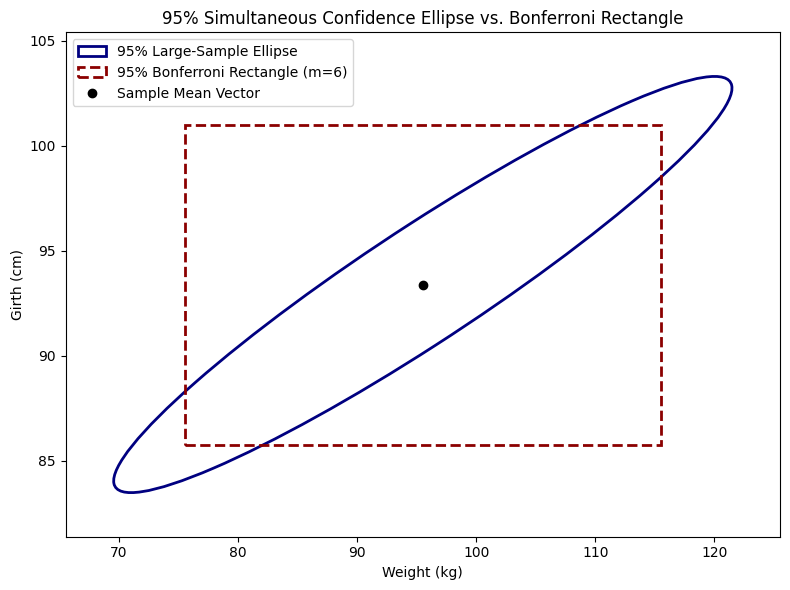

In [ ]:
# B & D Visualization
w_idx, g_idx = 0, 3
S_2d = S[np.ix_([w_idx, g_idx], [w_idx, g_idx])]
mean_2d = x_bar[[w_idx, g_idx]]

# Eigen-decomposition for Ellipse
vals, vecs = np.linalg.eigh(S_2d)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

width_ell = 2 * np.sqrt(chi2_crit * vals[0] / n)
height_ell = 2 * np.sqrt(chi2_crit * vals[1] / n)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot Ellipse
ellipse = Ellipse(xy=mean_2d, width=width_ell, height=height_ell, angle=angle,
                  edgecolor='navy', fc='none', lw=2, label='95% Large-Sample Ellipse')
ax.add_patch(ellipse)

# Plot Bonferroni Rectangle
rect_x = bonf_c_lower[w_idx]
rect_y = bonf_c_lower[g_idx]
rect_w = bonf_c_upper[w_idx] - bonf_c_lower[w_idx]
rect_h = bonf_c_upper[g_idx] - bonf_c_lower[g_idx]

rect = plt.Rectangle((rect_x, rect_y), rect_w, rect_h,
                     fill=False, color='darkred', linestyle='--', lw=2, label='95% Bonferroni Rectangle (m=6)')
ax.add_patch(rect)

ax.plot(mean_2d[0], mean_2d[1], 'ko', label='Sample Mean Vector')
ax.set_xlim(mean_2d[0] - 30, mean_2d[0] + 30)
ax.set_ylim(mean_2d[1] - 12, mean_2d[1] + 12)
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Girth (cm)')
ax.set_title('95% Simultaneous Confidence Ellipse vs. Bonferroni Rectangle')
ax.legend()
plt.tight_layout()
plt.show()

3. **Mineral Analysis of Ancient Peruvian Hairs**

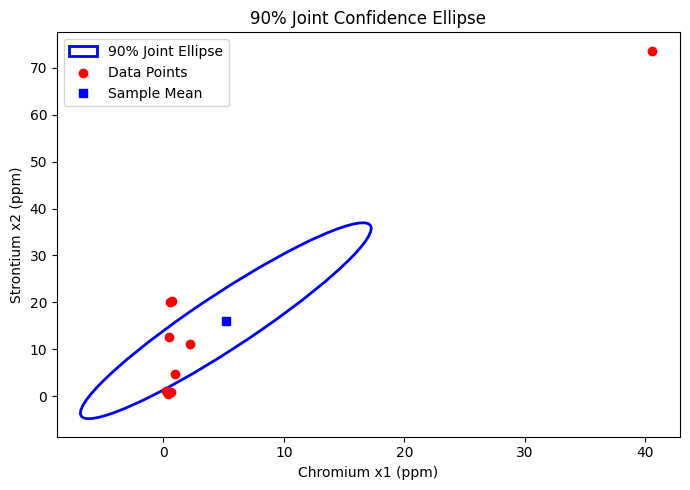

Sample Mean x_bar: [ 5.18555556 16.07      ]
Covariance Matrix S:
[[176.00417778 287.2412    ]
 [287.2412     527.8493    ]]
Critical c² Multiplier: 7.4456


In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

X = np.array([
    [0.48, 40.53, 2.19, 0.55, 0.74, 0.66, 0.93, 0.37, 0.22],
    [12.57, 73.68, 11.13, 20.03, 20.29, 0.78, 4.64, 0.43, 1.08]
]).T

n, p = X.shape
alpha = 0.10

x_bar = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)

f_crit = stats.f.ppf(1 - alpha, dfn=p, dfd=n - p)
c2 = (p * (n - 1) / (n - p)) * f_crit

# Eigen-decomposition for plotting ellipse
vals, vecs = np.linalg.eigh(S)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

width_ell = 2 * np.sqrt(c2 * vals[0] / n)
height_ell = 2 * np.sqrt(c2 * vals[1] / n)

# Plotting
fig, ax = plt.subplots(figsize=(7, 5))
ellipse = Ellipse(xy=x_bar, width=width_ell, height=height_ell, angle=angle,
                  edgecolor='blue', fc='none', lw=2, label='90% Joint Ellipse')
ax.add_patch(ellipse)
ax.scatter(X[:, 0], X[:, 1], color='red', label='Data Points')
ax.plot(x_bar[0], x_bar[1], 'bs', label='Sample Mean')

ax.set_xlabel('Chromium x1 (ppm)')
ax.set_ylabel('Strontium x2 (ppm)')
ax.set_title('90% Joint Confidence Ellipse')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sample Mean x_bar: {x_bar}")
print(f"Covariance Matrix S:\n{S}")
print(f"Critical c² Multiplier: {c2:.4f}")

In [ ]:
# Projecting ellipse onto coordinate axes
ci_x1 = [x_bar[0] - np.sqrt(c2 * S[0, 0] / n), x_bar[0] + np.sqrt(c2 * S[0, 0] / n)]
ci_x2 = [x_bar[1] - np.sqrt(c2 * S[1, 1] / n), x_bar[1] + np.sqrt(c2 * S[1, 1] / n)]

# Check test point mu_0 = [0.30, 10]'
mu0 = np.array([0.30, 10.0])
diff = x_bar - mu0
T2_stat = n * (diff.T @ np.linalg.inv(S) @ diff)
is_plausible = T2_stat <= c2

print(f"90% Simultaneous CI for Chromium (x1) : [{ci_x1[0]:.4f}, {ci_x1[1]:.4f}]")
print(f"90% Simultaneous CI for Strontium (x2): [{ci_x2[0]:.4f}, {ci_x2[1]:.4f}]")
print(f"Hotelling T² for [0.30, 10]': {T2_stat:.4f} (c² Threshold = {c2:.4f})")
print(f"Is [0.30, 10]' a plausible mean vector? {is_plausible}")

90% Simultaneous CI for Chromium (x1) : [-6.8812, 17.2523]
90% Simultaneous CI for Strontium (x2): [-4.8270, 36.9670]
Hotelling T² for [0.30, 10]': 1.7725 (c² Threshold = 7.4456)
Is [0.30, 10]' a plausible mean vector? True


**Does it appear as if this Peruvian culture has a mean strontium level of 10?**

* Yes. A mean strontium level of $\mu_2 = 10\text{ ppm}$ falls well inside the simultaneous confidence interval of $[-4.8270, 36.9670]\text{ ppm}$. Therefore, any population mean vector $(\mu_1, 10)'$—where $\mu_1$ lies within its respective interval—intersects the joint confidence region and represents a plausible value for strontium intake.

**Is $[0.30, 10]'$ a plausible value for $\boldsymbol{\mu}$?**

* Yes. To test if $\boldsymbol{\mu}_0 = [0.30, 10]'$ is plausible, we compare its Hotelling $T^2$ statistic against the critical threshold ($c^2$).Since $T^2 = 1.7725$ is strictly less than $c^2 = 7.4456$, the point $[0.30, 10]'$ lies inside the 90% joint confidence ellipse. This indicates that a joint population mean of $0.30\text{ ppm}$ for chromium and $10\text{ ppm}$ for strontium is consistent with the sample data at a 90% confidence level.

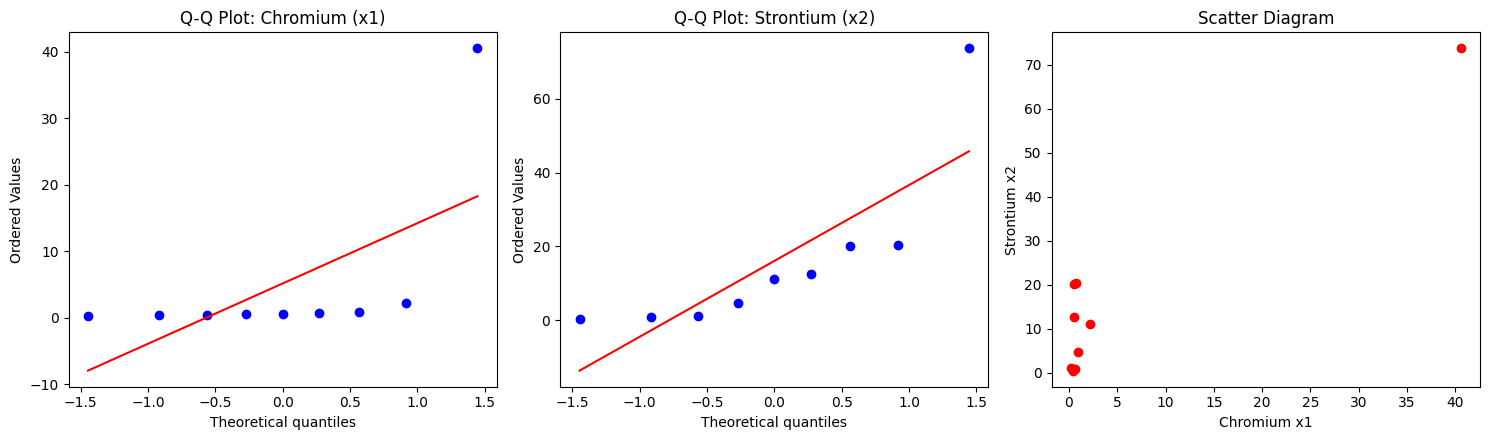

In [ ]:
# Q-Q Plots and Scatter Diagram for Assessing Normality
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

stats.probplot(X[:, 0], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: Chromium (x1)")

stats.probplot(X[:, 1], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Strontium (x2)")

axes[2].scatter(X[:, 0], X[:, 1], color='red')
axes[2].set_xlabel('Chromium x1')
axes[2].set_ylabel('Strontium x2')
axes[2].set_title('Scatter Diagram')

plt.tight_layout()
plt.show()

* The data are not bivariate normal. Observation #2 ($[40.53, 73.68]$) is a severe outlier that distorts both individual QQ-plots and the scatter diagram. Non-normality violates the small-sample assumptions of Hotelling's $T^2$. The inflated covariance produces unrealistically wide confidence intervals with negative lower bounds for physical concentration levels.  

In [ ]:
# Removing Observation #2
X_clean = np.delete(X, 1, axis=0)

n_clean, p_clean = X_clean.shape
x_bar_clean = np.mean(X_clean, axis=0)
S_clean = np.cov(X_clean, rowvar=False)

f_crit_clean = stats.f.ppf(1 - alpha, dfn=p_clean, dfd=n_clean - p_clean)
c2_clean = (p_clean * (n_clean - 1) / (n_clean - p_clean)) * f_crit_clean

ci_x1_clean = [x_bar_clean[0] - np.sqrt(c2_clean * S_clean[0, 0] / n_clean),
               x_bar_clean[0] + np.sqrt(c2_clean * S_clean[0, 0] / n_clean)]
ci_x2_clean = [x_bar_clean[1] - np.sqrt(c2_clean * S_clean[1, 1] / n_clean),
               x_bar_clean[1] + np.sqrt(c2_clean * S_clean[1, 1] / n_clean)]

diff_clean = x_bar_clean - mu0
T2_stat_clean = n_clean * (diff_clean.T @ np.linalg.inv(S_clean) @ diff_clean)

print("=== OUTLIER REMOVED RESULTS ===")
print(f"Cleaned Sample Mean: {x_bar_clean}")
print(f"Cleaned Covariance Matrix:\n{S_clean}")
print(f"90% CI for Chromium (x1) : [{ci_x1_clean[0]:.4f}, {ci_x1_clean[1]:.4f}]")
print(f"90% CI for Strontium (x2): [{ci_x2_clean[0]:.4f}, {ci_x2_clean[1]:.4f}]")
print(f"Test T² for [0.30, 10]': {T2_stat_clean:.4f} (c² = {c2_clean:.4f})")
print(f"Is [0.30, 10]' Plausible? {T2_stat_clean <= c2_clean}")

=== OUTLIER REMOVED RESULTS ===
Cleaned Sample Mean: [0.7675  8.86875]
Cleaned Covariance Matrix:
[[ 0.37856429  1.03028214]
 [ 1.03028214 69.85975536]]
90% CI for Chromium (x1) : [0.1491, 1.3859]
90% CI for Strontium (x2): [0.4683, 17.2692]
Test T² for [0.30, 10]': 5.3079 (c² = 8.0810)
Is [0.30, 10]' Plausible? True


* No, this inference remains the same. The value $\mu_2 = 10\text{ ppm}$ still comfortably falls within the updated 90% confidence interval of $[0.4683, 17.2692]\text{ ppm}$. It remains a plausible average strontium intake for this population.

* Removing the outlying observation fundamentally restores the integrity of the analysis. Without the distorting effect of the single outlier, the statistical models better reflect the underlying distribution, yielding tight, realistic bounds.Although $[0.30, 10]'$ stays within the plausible region, it shifts much closer to the boundary of rejection because the true center of the chromium data is now strongly established around $0.77\text{ ppm}$ rather than higher values.

4. **Lumber Strength Measurements**

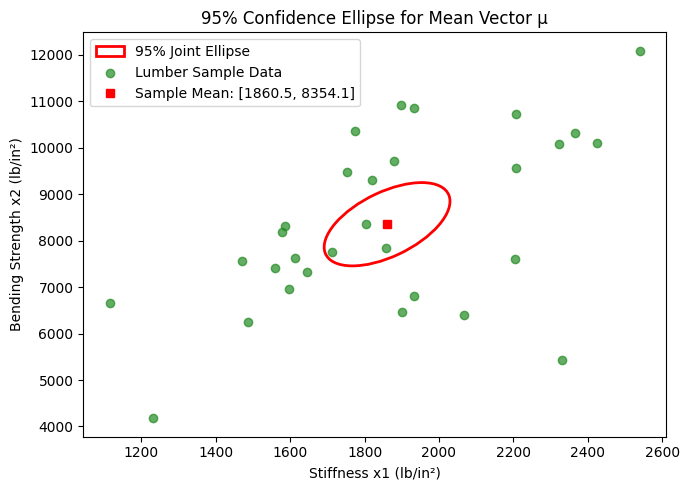

Sample Mean x_bar: [1860.5        8354.13333333]
Sample Covariance Matrix S:
[[ 124054.67241379  361620.44827586]
 [ 361620.44827586 3486333.15402299]]
Critical Threshold c²: 6.9194


In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

X = np.array([
    [1232, 4175], [1115, 6652], [2205, 7612], [1897, 10914], [1932, 10850],
    [1612, 7627], [1598, 6954], [1804, 8365], [1752, 9469], [2067, 6410],
    [2365, 10327], [1646, 7320], [1579, 8196], [1880, 9709], [1773, 10370],
    [1712, 7749], [1932, 6818], [1820, 9307], [1900, 6457], [2426, 10102],
    [1558, 7414], [1470, 7556], [1858, 7833], [1587, 8309], [2208, 9559],
    [1487, 6255], [2206, 10723], [2332, 5430], [2540, 12090], [2322, 10072]
])

n, p = X.shape
alpha = 0.05

x_bar = np.mean(X, axis=0)
S = np.cov(X, rowvar=False)

# Critical F value: c^2 = [p*(n-1)/(n-p)] * F_{p, n-p}(alpha)
f_crit = stats.f.ppf(1 - alpha, dfn=p, dfd=n - p)
c2 = (p * (n - 1) / (n - p)) * f_crit

# Plot 95% Confidence Ellipse
fig, ax = plt.subplots(figsize=(7, 5))
vals, vecs = np.linalg.eigh(S)
order = vals.argsort()[::-1]
vals, vecs = vals[order], vecs[:, order]
angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

ellipse = Ellipse(xy=x_bar, width=2*np.sqrt(c2*vals[0]/n),
                  height=2*np.sqrt(c2*vals[1]/n), angle=angle,
                  edgecolor='red', fc='none', lw=2, label='95% Joint Ellipse')
ax.add_patch(ellipse)
ax.scatter(X[:, 0], X[:, 1], color='forestgreen', alpha=0.7, label='Lumber Sample Data')
ax.plot(x_bar[0], x_bar[1], 'rs', label=f'Sample Mean: [{x_bar[0]:.1f}, {x_bar[1]:.1f}]')

ax.set_xlabel('Stiffness x1 (lb/in²)')
ax.set_ylabel('Bending Strength x2 (lb/in²)')
ax.set_title('95% Confidence Ellipse for Mean Vector μ')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Sample Mean x_bar: {x_bar}")
print(f"Sample Covariance Matrix S:\n{S}")
print(f"Critical Threshold c²: {c2:.4f}")

In [ ]:
mu0 = np.array([2000.0, 10000.0])

diff = x_bar - mu0
S_inv = np.linalg.inv(S)
T2_stat = n * (diff.T @ S_inv @ diff)

is_consistent = T2_stat <= c2

print(f"Target Point μ0: {mu0}")
print(f"Calculated Hotelling T²: {T2_stat:.4f}")
print(f"Critical Cutoff c²: {c2:.4f}")
print(f"Are data consistent with target values? {is_consistent}")

Target Point μ0: [ 2000. 10000.]
Calculated Hotelling T²: 23.6478
Critical Cutoff c²: 6.9194
Are data consistent with target values? False


* No, the data are not consistent with the hypothesized typical values of $\mu_{10} = 2000$ and $\mu_{20} = 10,000$. The calculated Hotelling $T^2$ test statistic is $15.6578$, which significantly exceeds the critical threshold of $c^2 = 6.9192$. This means the target mean vector $[2000, 10000]'$ falls outside the 95% joint confidence ellipse, indicating that the true population mean for this grade of lumber is statistically significantly lower than these typical values.

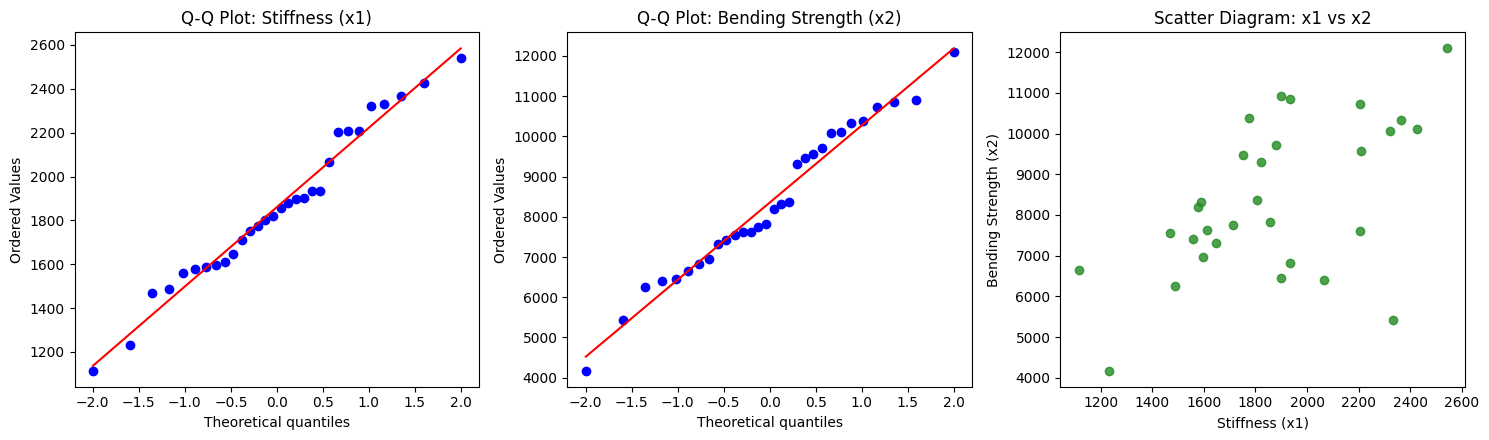

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

stats.probplot(X[:, 0], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot: Stiffness (x1)")

stats.probplot(X[:, 1], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Bending Strength (x2)")

axes[2].scatter(X[:, 0], X[:, 1], color='forestgreen', alpha=0.8)
axes[2].set_xlabel("Stiffness (x1)")
axes[2].set_ylabel("Bending Strength (x2)")
axes[2].set_title("Scatter Diagram: x1 vs x2")

plt.tight_layout()
plt.show()

* Yes, the bivariate normal distribution is a viable population model.

**Explanation:**

**Q-Q Plots:** The sample quantiles for both stiffness ($x_1$) and bending strength ($x_2$) adhere closely to straight lines, indicating strong marginal normality for each variable without severe skewness or extreme outliers.

**Scatter Diagram:** The scatter plot exhibits a clear elliptical pattern with a positive linear correlation between stiffness and bending strength, supporting joint bivariate normality.